# Boss DS-1 Neural Emulation Analysis

This notebook analyzes the completed DS-1 neural emulation runs for the LSTM and GRU recurrent models. It is analysis-only: it loads existing artifacts from `Results/`, training statistics from `notebook_stats/`, and audio from `Data/`. It does not retrain models or run inference.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from IPython.display import display, Markdown, HTML

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = ROOT / "Results"
STATS_DIR = ROOT / "notebook_stats"
DEVICE = "ds1"

RUNS = {
    "LSTM": {"run_key": "ds1_LSTM", "result_dir": RESULTS_DIR / "ds1-LSTM", "stats_path": STATS_DIR / "ds1_LSTM_stats.json"},
    "GRU": {"run_key": "ds1_GRU", "result_dir": RESULTS_DIR / "ds1-GRU", "stats_path": STATS_DIR / "ds1_GRU_stats.json"},
}

TRAINING_PIPELINE = {
    "Seed": 0,
    "Epoch limit": 500,
    "Optimizer": "Adam",
    "Initial learning rate": 0.005,
    "Weight decay": 1e-4,
    "LR scheduler": "ReduceLROnPlateau, factor=0.5, patience=5",
    "Batch size": 50,
    "Training segment length": 22050,
    "Initial recurrent state length": 200,
    "Truncated update frame": 1000,
    "Validation frequency": "Every 2 epochs",
    "Early stopping patience": "25 validation checks without improvement",
    "Loss": "0.75 * ESRPre + 0.25 * DC",
    "Pre-emphasis filter": "[-0.85, 1]",
    "Validation chunk": 100000,
    "Test chunk": 100000,
}


## Helper Functions

These functions load artifacts, normalize audio, compute model size, and calculate time-domain and frequency-domain metrics.


In [2]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return path


def load_json(path: Path):
    with require_file(path).open() as f:
        return json.load(f)


def count_scalars(value):
    if isinstance(value, list):
        return sum(count_scalars(item) for item in value)
    return 1


def read_wav_float(path: Path):
    fs, data = wavfile.read(require_file(path))
    data = np.asarray(data)
    if data.ndim > 1:
        data = data[:, 0]
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / float(np.iinfo(data.dtype).max)
    else:
        data = data.astype(np.float64)
    return fs, data


def align_audio(*arrays):
    n = min(len(x) for x in arrays)
    return [x[:n] for x in arrays]


def db(value, floor=1e-12):
    return 20 * np.log10(np.maximum(np.asarray(value), floor))


def audio_basic_stats(path: Path):
    fs, x = read_wav_float(path)
    return {
        "Path": str(path.relative_to(ROOT)),
        "Sample Rate (Hz)": fs,
        "Samples": len(x),
        "Duration (s)": len(x) / fs,
        "Mean": float(np.mean(x)),
        "RMS": float(np.sqrt(np.mean(x ** 2))),
        "Peak Abs": float(np.max(np.abs(x))),
        "Min": float(np.min(x)),
        "Max": float(np.max(x)),
    }


def objective_metrics(target, output):
    target, output = align_audio(target, output)
    err = output - target
    mse = float(np.mean(err ** 2))
    target_energy = float(np.sum(target ** 2))
    err_energy = float(np.sum(err ** 2))
    return {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(np.mean(np.abs(err))),
        "ESR": err_energy / max(target_energy, 1e-12),
        "SNR (dB)": 10 * math.log10(max(target_energy, 1e-12) / max(err_energy, 1e-12)),
        "Correlation": float(np.corrcoef(target, output)[0, 1]) if np.std(target) > 0 and np.std(output) > 0 else np.nan,
        "Peak Abs Error": float(np.max(np.abs(err))),
        "Mean Error": float(np.mean(err)),
        "Target Peak": float(np.max(np.abs(target))),
        "Output Peak": float(np.max(np.abs(output))),
        "Output RMS": float(np.sqrt(np.mean(output ** 2))),
        "Clip Count >= 0.999": int(np.sum(np.abs(output) >= 0.999)),
    }


def spectral_metrics(target, output, fs, nperseg=4096, noverlap=2048):
    target, output = align_audio(target, output)
    freqs, _, zt = signal.stft(target, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
    _, _, zo = signal.stft(output, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
    mag_t = np.abs(zt)
    mag_o = np.abs(zo)
    err_db = np.abs(db(mag_o) - db(mag_t))
    bands = [("20-100 Hz",20,100),("100-500 Hz",100,500),("500 Hz-2 kHz",500,2000),("2-5 kHz",2000,5000),("5-10 kHz",5000,10000),("10-20 kHz",10000,min(20000,fs/2))]
    rows = []
    for label, lo, hi in bands:
        mask = (freqs >= lo) & (freqs < hi)
        rows.append({"Band": label, "Mean Abs Spectral Error (dB)": float(np.mean(err_db[mask])) if np.any(mask) else np.nan, "Median Abs Spectral Error (dB)": float(np.median(err_db[mask])) if np.any(mask) else np.nan})
    return pd.DataFrame(rows), freqs, mag_t, mag_o


def html_audio_player(label, path: Path):
    rel = path.relative_to(ROOT).as_posix()
    html = "<div style='margin:0.6rem 0'><div style='font-weight:600; margin-bottom:0.2rem'>{}</div><audio controls src='{}' style='width:100%'></audio><div style='font-family:monospace; font-size:0.85rem'>{}</div></div>".format(label, rel, rel)
    return HTML(html)


## Artifact Inventory

This check confirms that the notebook is using the expected saved model, stats, and audio-output artifacts.


In [3]:
artifact_rows = []
for name, run in RUNS.items():
    for label, path in [
        ("stats", run["stats_path"]),
        ("model_best", run["result_dir"] / "model_best.json"),
        ("model_final", run["result_dir"] / "model.json"),
        ("test_output_best", run["result_dir"] / "test_out_bestv.wav"),
        ("test_output_final", run["result_dir"] / "test_out_final.wav"),
        ("validation_output_best", run["result_dir"] / "best_val_out.wav"),
    ]:
        artifact_rows.append({"Run": name, "Artifact": label, "Path": str(path.relative_to(ROOT)), "Exists": path.exists(), "Size (MB)": path.stat().st_size / (1024 ** 2) if path.exists() else np.nan})
artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df.style.format({"Size (MB)": "{:.3f}"}).hide(axis="index"))
missing = artifact_df.loc[~artifact_df["Exists"]]
if not missing.empty:
    raise FileNotFoundError("Missing required artifacts:\n" + missing.to_string(index=False))


Run,Artifact,Path,Exists,Size (MB)
LSTM,stats,notebook_stats/ds1_LSTM_stats.json,True,0.021
LSTM,model_best,Results/ds1-LSTM/model_best.json,True,0.055
LSTM,model_final,Results/ds1-LSTM/model.json,True,0.055
LSTM,test_output_best,Results/ds1-LSTM/test_out_bestv.wav,True,10.094
LSTM,test_output_final,Results/ds1-LSTM/test_out_final.wav,True,10.094
LSTM,validation_output_best,Results/ds1-LSTM/best_val_out.wav,True,8.590
GRU,stats,notebook_stats/ds1_GRU_stats.json,True,0.009
GRU,model_best,Results/ds1-GRU/model_best.json,True,0.041
GRU,model_final,Results/ds1-GRU/model.json,True,0.041
GRU,test_output_best,Results/ds1-GRU/test_out_bestv.wav,True,10.094


## Dataset Summary

The train, validation, and test WAV files are summarized directly. This documents the data used by the training and evaluation pipelines.


In [4]:
dataset_rows = []
for split in ["train", "val", "test"]:
    for signal_name in ["input", "target"]:
        path = DATA_DIR / split / f"{DEVICE}-{signal_name}.wav"
        row = audio_basic_stats(path)
        row.update({"Split": split, "Signal": signal_name})
        dataset_rows.append(row)

df_dataset = pd.DataFrame(dataset_rows)[["Split", "Signal", "Sample Rate (Hz)", "Samples", "Duration (s)", "Mean", "RMS", "Peak Abs", "Min", "Max", "Path"]]
display(df_dataset.style.format({"Duration (s)":"{:.2f}", "Mean":"{:.6f}", "RMS":"{:.6f}", "Peak Abs":"{:.6f}", "Min":"{:.6f}", "Max":"{:.6f}"}).hide(axis="index"))


Split,Signal,Sample Rate (Hz),Samples,Duration (s),Mean,RMS,Peak Abs,Min,Max,Path
train,input,44100,14994001,340.00,-0.000015,0.069594,0.550920,-0.543962,0.550920,Data/train/ds1-input.wav
train,target,44100,14994001,340.00,-0.000000,0.089206,0.432600,-0.432600,0.277078,Data/train/ds1-target.wav
val,input,44100,2251753,51.06,-0.000016,0.066855,0.552324,-0.519456,0.552324,Data/val/ds1-input.wav
val,target,44100,2251753,51.06,0.000000,0.084724,0.384716,-0.384716,0.265389,Data/val/ds1-target.wav
test,input,44100,2646001,60.00,-0.000015,0.102890,0.565722,-0.565722,0.562639,Data/test/ds1-input.wav
test,target,44100,2646001,60.00,-0.000000,0.115847,0.394543,-0.394543,0.301004,Data/test/ds1-target.wav


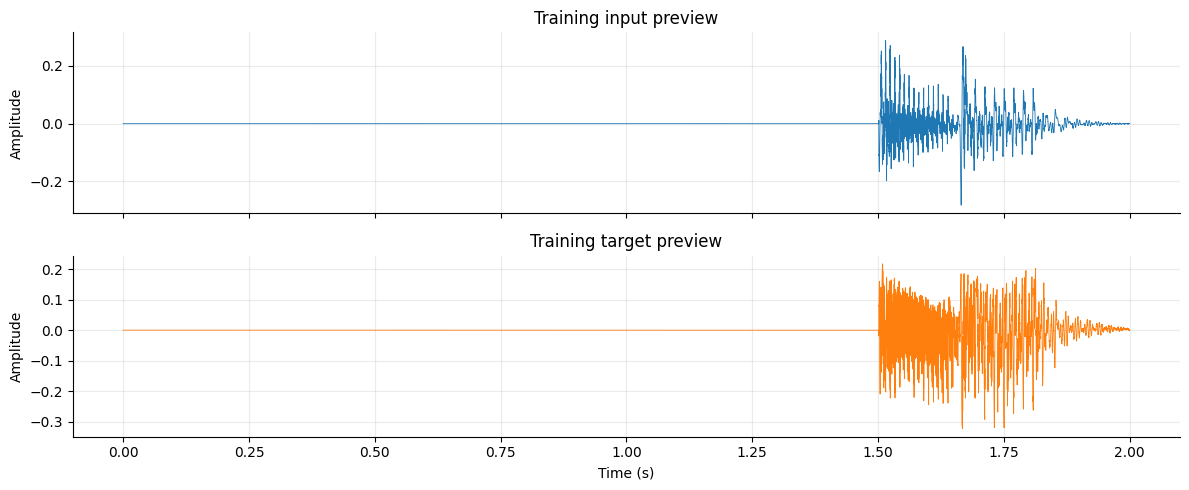

In [5]:
fs_train, train_in = read_wav_float(DATA_DIR / "train" / f"{DEVICE}-input.wav")
_, train_target = read_wav_float(DATA_DIR / "train" / f"{DEVICE}-target.wav")
n = int(2 * fs_train)
t = np.arange(n) / fs_train
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, train_in[:n], lw=0.6)
axes[0].set_title("Training input preview")
axes[0].set_ylabel("Amplitude")
axes[1].plot(t, train_target[:n], lw=0.6, color="C1")
axes[1].set_title("Training target preview")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Model Architecture Comparison

Both models use the `SimpleRNN` wrapper with single-channel input/output, one recurrent layer, a 24-unit hidden state, and a skip connection. The key architectural difference is the recurrent cell type.


In [6]:
model_rows = []
for name, run in RUNS.items():
    model = load_json(run["result_dir"] / "model_best.json")
    mdict = model["model_data"]
    param_count = sum(count_scalars(v) for v in model["state_dict"].values())
    model_rows.append({"Run": name, "Model": mdict.get("model"), "Unit Type": mdict.get("unit_type"), "Hidden Size": mdict.get("hidden_size"), "Layers": mdict.get("num_layers"), "Input Size": mdict.get("input_size"), "Output Size": mdict.get("output_size"), "Skip Connection": bool(mdict.get("skip")), "Bias": bool(mdict.get("bias_fl")), "Parameters": param_count, "Best Model Path": str((run["result_dir"] / "model_best.json").relative_to(ROOT))})
df_models = pd.DataFrame(model_rows)
display(df_models.style.hide(axis="index"))


Run,Model,Unit Type,Hidden Size,Layers,Input Size,Output Size,Skip Connection,Bias,Parameters,Best Model Path
LSTM,SimpleRNN,LSTM,24,1,1,1,True,True,2617,Results/ds1-LSTM/model_best.json
GRU,SimpleRNN,GRU,24,1,1,1,True,True,1969,Results/ds1-GRU/model_best.json


## Training Pipeline

The following table records the training settings from the original training notebook so this analysis is self-contained.


In [7]:
df_pipeline = pd.DataFrame([{"Setting": key, "Value": value} for key, value in TRAINING_PIPELINE.items()])
display(df_pipeline.style.hide(axis="index"))


Setting,Value
Seed,0
Epoch limit,500
Optimizer,Adam
Initial learning rate,0.005000
Weight decay,0.000100
LR scheduler,"ReduceLROnPlateau, factor=0.5, patience=5"
Batch size,50
Training segment length,22050
Initial recurrent state length,200
Truncated update frame,1000


## Training Dynamics

Saved training statistics are used to compare convergence, validation behavior, learning-rate decay, early stopping, and final-versus-best checkpoint performance.


In [8]:
stats = {name: load_json(run["stats_path"]) for name, run in RUNS.items()}
summary_rows = []
for name, s in stats.items():
    summary_rows.append({"Run": name, "Epochs Run": s["total_epochs_run"], "Stopped Early": s["stopped_early"], "Best Epoch": s["best_epoch"], "Best Val Loss": s["best_val_loss"], "Final Train Loss": s["train_losses"][-1], "Test Loss Final": s["test_loss_final"], "Test ESR Final": s["test_loss_esr_final"], "Test Loss Best Val": s["test_loss_best"], "Test ESR Best Val": s["test_loss_esr_best"], "Training Time (h)": s["training_time_seconds"] / 3600, "Seconds / Epoch": s["training_time_seconds"] / max(s["total_epochs_run"], 1)})
df_training_summary = pd.DataFrame(summary_rows)
display(df_training_summary.style.format({"Best Val Loss":"{:.6f}", "Final Train Loss":"{:.6f}", "Test Loss Final":"{:.6f}", "Test ESR Final":"{:.6f}", "Test Loss Best Val":"{:.6f}", "Test ESR Best Val":"{:.6f}", "Training Time (h)":"{:.2f}", "Seconds / Epoch":"{:.2f}"}).hide(axis="index"))


Run,Epochs Run,Stopped Early,Best Epoch,Best Val Loss,Final Train Loss,Test Loss Final,Test ESR Final,Test Loss Best Val,Test ESR Best Val,Training Time (h),Seconds / Epoch
LSTM,336,True,284,0.023025,0.021342,0.027128,0.021446,0.027176,0.021395,4.46,47.79
GRU,138,True,86,0.037394,0.027822,0.041957,0.037634,0.037898,0.035911,3.53,92.16


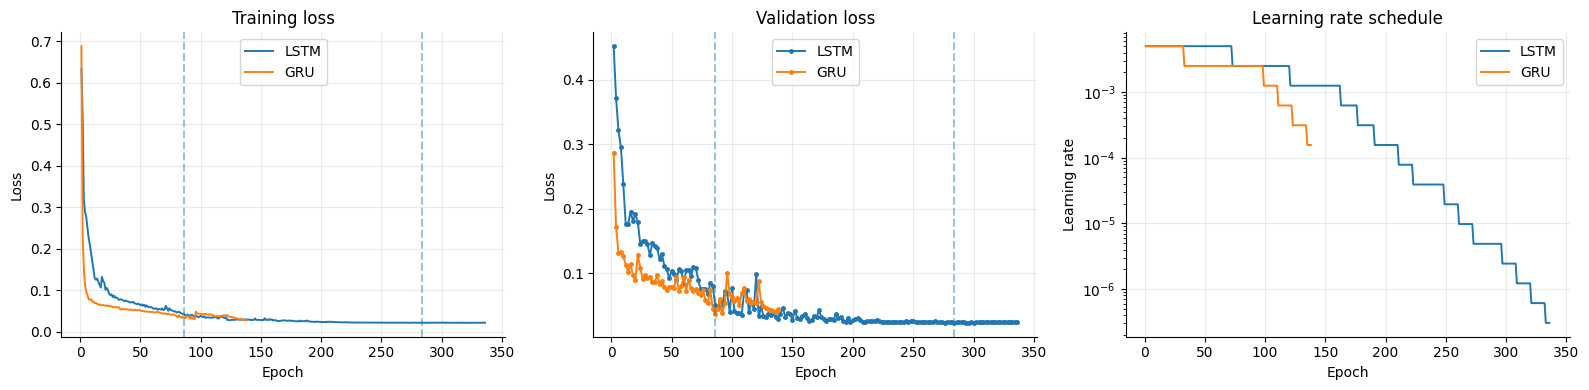

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, s in stats.items():
    epochs = np.arange(1, len(s["train_losses"]) + 1)
    axes[0].plot(epochs, s["train_losses"], label=name, lw=1.4)
    axes[0].axvline(s["best_epoch"], ls="--", alpha=0.45)
    val_epochs, val_losses = zip(*s["val_losses"])
    axes[1].plot(val_epochs, val_losses, label=name, lw=1.4, marker="o", ms=2.5)
    axes[1].axvline(s["best_epoch"], ls="--", alpha=0.45)
    axes[2].plot(epochs, s["learning_rates"], label=name, lw=1.4)
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[2].set_title("Learning rate schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_yscale("log")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


In [10]:
rows = []
for name, s in stats.items():
    row = {"Run": name, "Best Epoch": s["best_epoch"], "Best Val Loss": s["best_val_loss"], "Final Validation Loss": s["val_losses"][-1][1], "Final Train Loss": s["train_losses"][-1], "Generalization Gap at Best Epoch": s["best_val_loss"] - s["train_losses"][s["best_epoch"] - 1], "Post-best Epochs": s["total_epochs_run"] - s["best_epoch"]}
    for th in [0.10, 0.05, 0.04, 0.03]:
        reached = [ep for ep, loss in s["val_losses"] if loss <= th]
        row[f"First Val <= {th}"] = reached[0] if reached else np.nan
    rows.append(row)
df_convergence = pd.DataFrame(rows)
display(df_convergence.style.format({"Best Val Loss":"{:.6f}", "Final Validation Loss":"{:.6f}", "Final Train Loss":"{:.6f}", "Generalization Gap at Best Epoch":"{:.6f}"}).hide(axis="index"))


Run,Best Epoch,Best Val Loss,Final Validation Loss,Final Train Loss,Generalization Gap at Best Epoch,Post-best Epochs,First Val <= 0.1,First Val <= 0.05,First Val <= 0.04,First Val <= 0.03
LSTM,284,0.023025,0.023741,0.021342,0.001905,52,48,88,104,138.000000
GRU,86,0.037394,0.044003,0.027822,0.003760,52,18,84,86,nan


## Objective Test-Audio Metrics

The saved model outputs are compared sample-by-sample against the test target. Best-validation checkpoints are the primary research comparison, while final checkpoints show the effect of checkpoint selection.


In [11]:
fs_test, test_input = read_wav_float(DATA_DIR / "test" / f"{DEVICE}-input.wav")
fs_target, test_target = read_wav_float(DATA_DIR / "test" / f"{DEVICE}-target.wav")
assert fs_test == fs_target

outputs = {}
metric_rows = []
for name, run in RUNS.items():
    outputs[name] = {}
    for checkpoint, filename in [("Best Val", "test_out_bestv.wav"), ("Final", "test_out_final.wav")]:
        fs_out, output = read_wav_float(run["result_dir"] / filename)
        assert fs_out == fs_target
        outputs[name][checkpoint] = output
        row = objective_metrics(test_target, output)
        row.update({"Run": name, "Checkpoint": checkpoint})
        metric_rows.append(row)

df_audio_metrics = pd.DataFrame(metric_rows)[["Run", "Checkpoint", "MSE", "RMSE", "MAE", "ESR", "SNR (dB)", "Correlation", "Peak Abs Error", "Mean Error", "Target Peak", "Output Peak", "Output RMS", "Clip Count >= 0.999"]]
display(df_audio_metrics.style.format({"MSE":"{:.8f}", "RMSE":"{:.6f}", "MAE":"{:.6f}", "ESR":"{:.6f}", "SNR (dB)":"{:.2f}", "Correlation":"{:.6f}", "Peak Abs Error":"{:.6f}", "Mean Error":"{:.8f}", "Target Peak":"{:.6f}", "Output Peak":"{:.6f}", "Output RMS":"{:.6f}"}).hide(axis="index"))


Run,Checkpoint,MSE,RMSE,MAE,ESR,SNR (dB),Correlation,Peak Abs Error,Mean Error,Target Peak,Output Peak,Output RMS,Clip Count >= 0.999
LSTM,Best Val,0.00028735,0.016951,0.011324,0.021411,16.69,0.989516,0.309831,0.00272195,0.394543,0.412847,0.114650,0
LSTM,Final,0.00028802,0.016971,0.011265,0.021462,16.68,0.989433,0.310072,0.00242661,0.394543,0.411836,0.114570,0
GRU,Best Val,0.00048230,0.021961,0.015448,0.035938,14.44,0.981887,0.321065,-0.00045629,0.394543,0.393314,0.113179,0
GRU,Final,0.00050546,0.022482,0.015094,0.037663,14.24,0.981595,0.304666,-0.00377702,0.394543,0.382126,0.112460,0


In [12]:
best_val = df_training_summary.sort_values("Best Val Loss").iloc[0]
best_esr = df_audio_metrics[df_audio_metrics["Checkpoint"] == "Best Val"].sort_values("ESR").iloc[0]
fastest = df_training_summary.sort_values("Training Time (h)").iloc[0]
smallest = df_models.sort_values("Parameters").iloc[0]
display(Markdown(f"""
### Objective Findings

- Lowest saved validation loss: **{best_val['Run']}** at epoch **{int(best_val['Best Epoch'])}** with validation loss **{best_val['Best Val Loss']:.6f}**.
- Lowest best-checkpoint test ESR from direct waveform metrics: **{best_esr['Run']}** with ESR **{best_esr['ESR']:.6f}** and SNR **{best_esr['SNR (dB)']:.2f} dB**.
- Smallest model: **{smallest['Run']}** with **{int(smallest['Parameters'])}** parameters.
- Shorter training time: **{fastest['Run']}** at **{fastest['Training Time (h)']:.2f} h**.
"""))



### Objective Findings

- Lowest saved validation loss: **LSTM** at epoch **284** with validation loss **0.023025**.
- Lowest best-checkpoint test ESR from direct waveform metrics: **LSTM** with ESR **0.021411** and SNR **16.69 dB**.
- Smallest model: **GRU** with **1969** parameters.
- Shorter training time: **GRU** at **3.53 h**.


## Time-Domain Error Analysis

These plots compare each best-validation output to the target and show residual error structure.


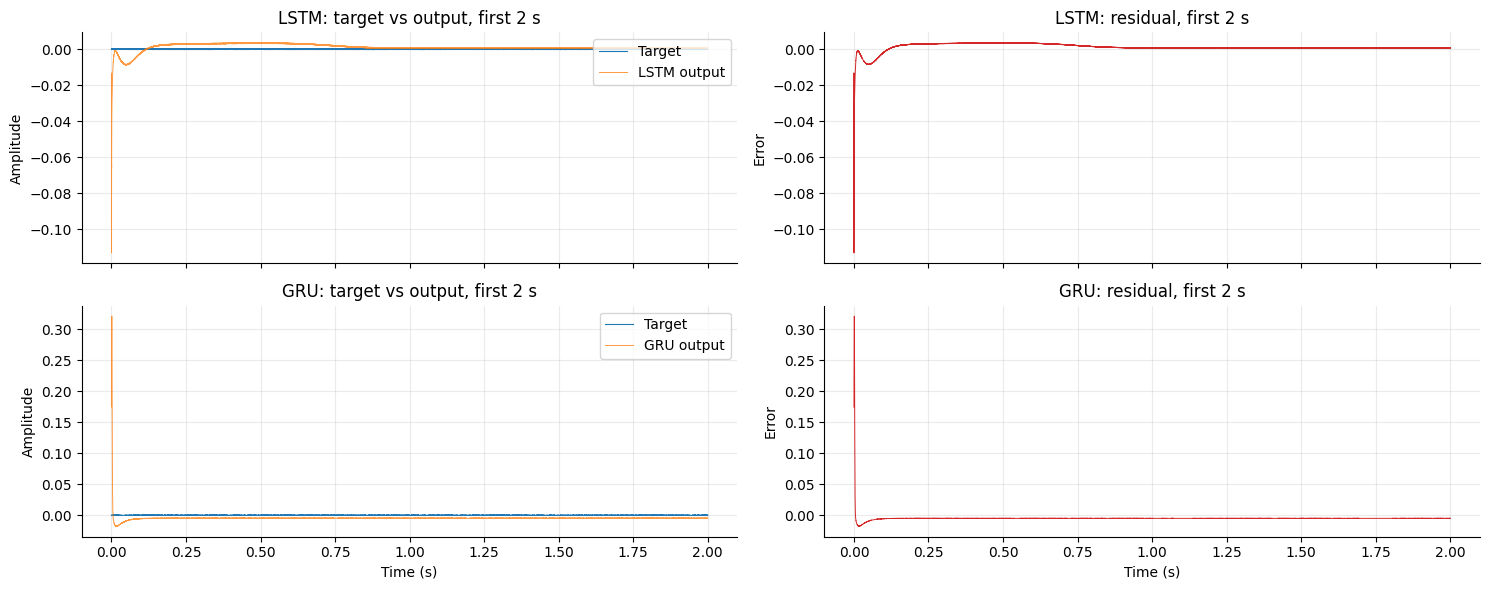

In [13]:
n = int(2 * fs_target)
t = np.arange(n) / fs_target
fig, axes = plt.subplots(len(RUNS), 2, figsize=(15, 6), sharex="col")
for row_idx, (name, run_outputs) in enumerate(outputs.items()):
    target, output = align_audio(test_target, run_outputs["Best Val"])
    err = output - target
    axes[row_idx, 0].plot(t, target[:n], label="Target", lw=0.8)
    axes[row_idx, 0].plot(t, output[:n], label=f"{name} output", lw=0.7, alpha=0.8)
    axes[row_idx, 0].set_title(f"{name}: target vs output, first 2 s")
    axes[row_idx, 0].set_ylabel("Amplitude")
    axes[row_idx, 0].legend(loc="upper right")
    axes[row_idx, 1].plot(t, err[:n], color="C3", lw=0.7)
    axes[row_idx, 1].set_title(f"{name}: residual, first 2 s")
    axes[row_idx, 1].set_ylabel("Error")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


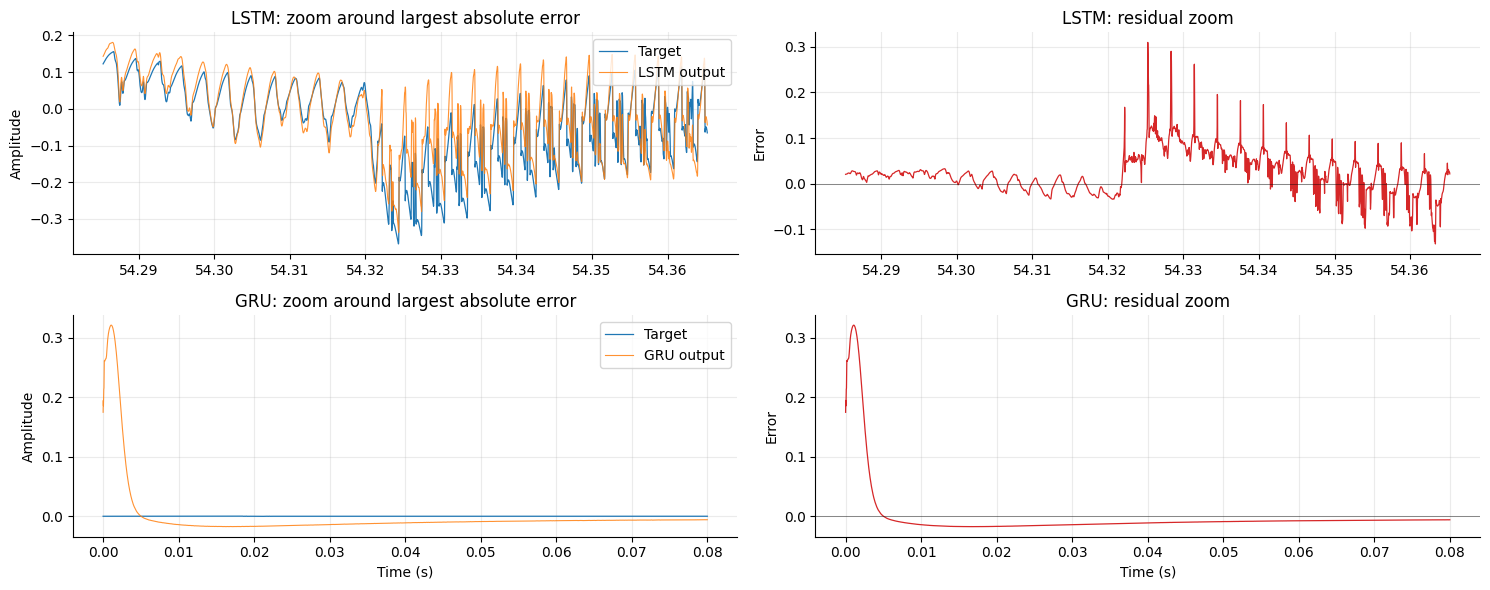

In [14]:
zoom_n = int(fs_target * 0.08)
fig, axes = plt.subplots(len(RUNS), 2, figsize=(15, 6))
for row_idx, (name, run_outputs) in enumerate(outputs.items()):
    target, output = align_audio(test_target, run_outputs["Best Val"])
    err = output - target
    center = int(np.argmax(np.abs(err)))
    start = max(0, center - zoom_n // 2)
    stop = min(len(target), start + zoom_n)
    tt = np.arange(start, stop) / fs_target
    axes[row_idx, 0].plot(tt, target[start:stop], label="Target", lw=0.9)
    axes[row_idx, 0].plot(tt, output[start:stop], label=f"{name} output", lw=0.8, alpha=0.85)
    axes[row_idx, 0].set_title(f"{name}: zoom around largest absolute error")
    axes[row_idx, 0].set_ylabel("Amplitude")
    axes[row_idx, 0].legend(loc="upper right")
    axes[row_idx, 1].plot(tt, err[start:stop], color="C3", lw=0.9)
    axes[row_idx, 1].axhline(0, color="black", lw=0.6, alpha=0.5)
    axes[row_idx, 1].set_title(f"{name}: residual zoom")
    axes[row_idx, 1].set_ylabel("Error")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


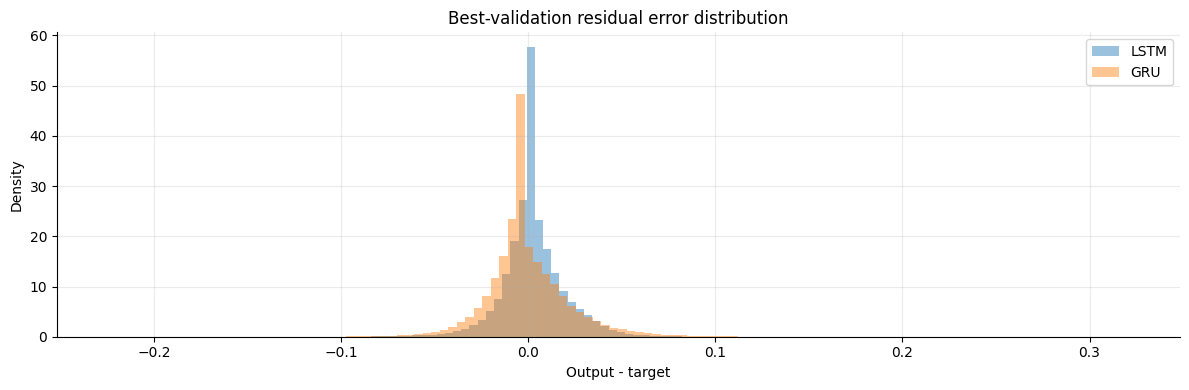

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, run_outputs in outputs.items():
    target, output = align_audio(test_target, run_outputs["Best Val"])
    ax.hist(output - target, bins=120, alpha=0.45, density=True, label=name)
ax.set_title("Best-validation residual error distribution")
ax.set_xlabel("Output - target")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


## Frequency-Domain Analysis

Spectral analysis shows whether each model matches the target energy distribution across frequency bands. This matters for distortion modeling because audible differences often appear in harmonic and high-frequency residual structure.


In [16]:
spectral_tables = []
spectral_cache = {}
for name, run_outputs in outputs.items():
    band_df, freqs, mag_t, mag_o = spectral_metrics(test_target, run_outputs["Best Val"], fs_target)
    band_df.insert(0, "Run", name)
    spectral_tables.append(band_df)
    spectral_cache[name] = {"freqs": freqs, "target_mag": mag_t, "output_mag": mag_o}
df_spectral = pd.concat(spectral_tables, ignore_index=True)
display(df_spectral.style.format({"Mean Abs Spectral Error (dB)":"{:.3f}", "Median Abs Spectral Error (dB)":"{:.3f}"}).hide(axis="index"))


Run,Band,Mean Abs Spectral Error (dB),Median Abs Spectral Error (dB)
LSTM,20-100 Hz,3.481,1.494
LSTM,100-500 Hz,1.933,1.042
LSTM,500 Hz-2 kHz,3.023,1.564
LSTM,2-5 kHz,4.795,2.143
LSTM,5-10 kHz,5.251,2.771
LSTM,10-20 kHz,11.572,11.585
GRU,20-100 Hz,3.757,1.877
GRU,100-500 Hz,2.224,1.253
GRU,500 Hz-2 kHz,3.182,1.528
GRU,2-5 kHz,5.033,2.251


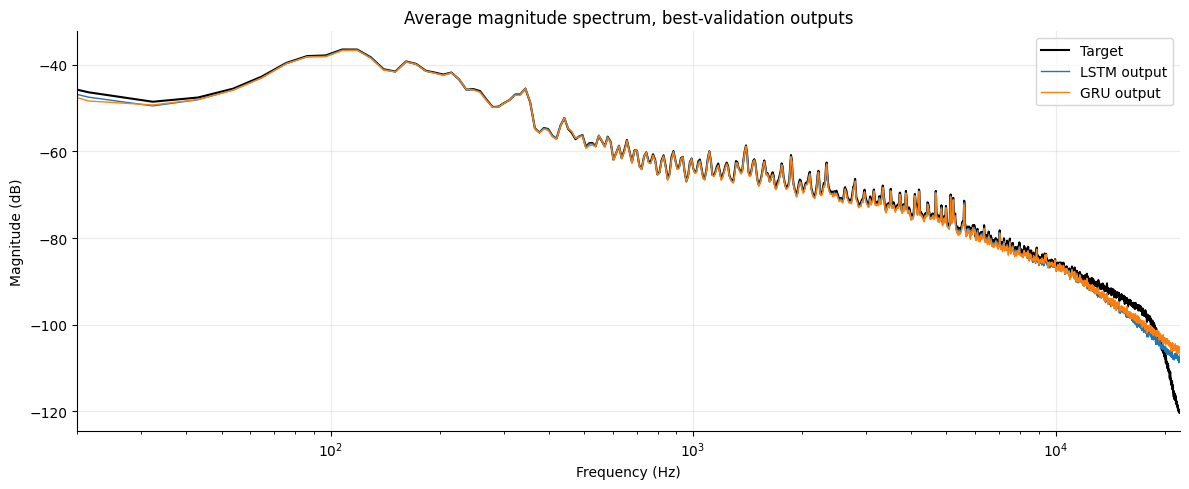

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
for idx, (name, cache) in enumerate(spectral_cache.items()):
    freqs = cache["freqs"]
    target_avg = np.mean(cache["target_mag"], axis=1)
    output_avg = np.mean(cache["output_mag"], axis=1)
    if idx == 0:
        ax.semilogx(freqs[1:], db(target_avg[1:]), color="black", lw=1.5, label="Target")
    ax.semilogx(freqs[1:], db(output_avg[1:]), lw=1.0, label=f"{name} output")
ax.set_title("Average magnitude spectrum, best-validation outputs")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(20, fs_target / 2)
ax.legend()
plt.tight_layout()
plt.show()


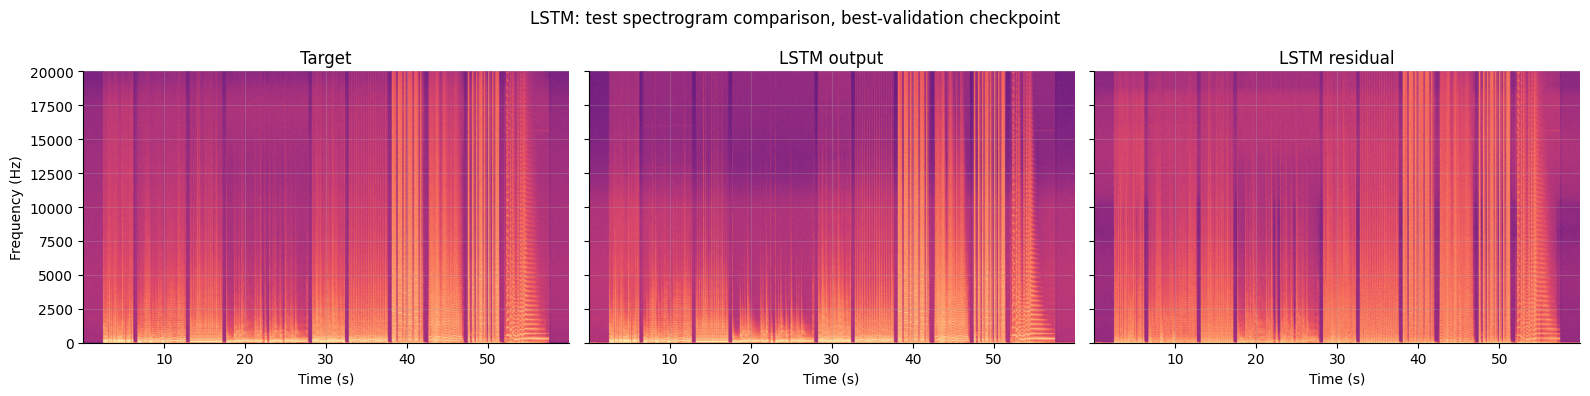

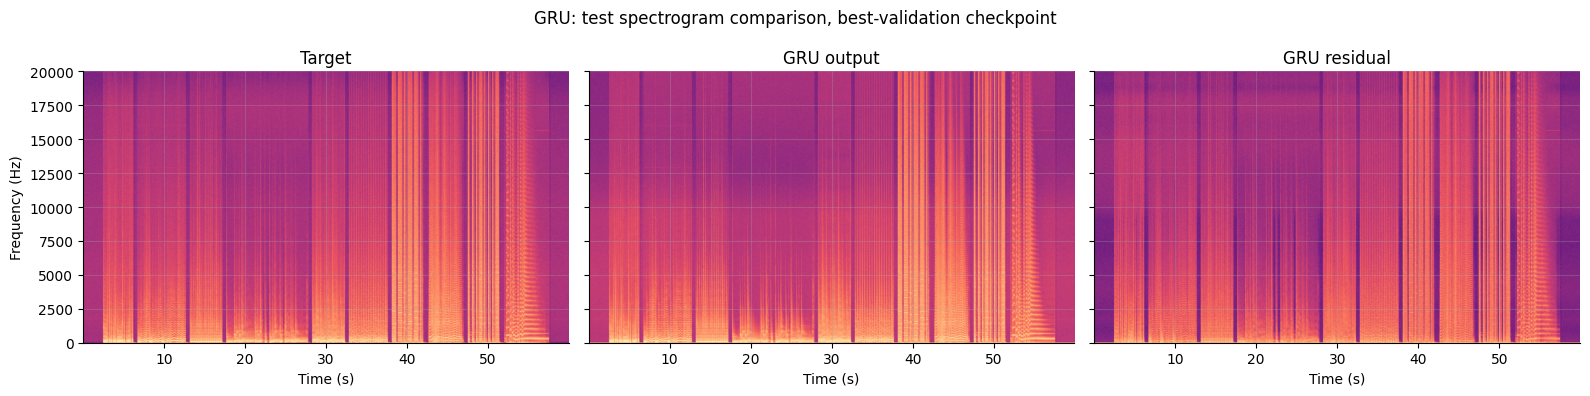

In [18]:
for name, run_outputs in outputs.items():
    target, output = align_audio(test_target, run_outputs["Best Val"])
    err = output - target
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, x, title in [(axes[0], target, "Target"), (axes[1], output, f"{name} output"), (axes[2], err, f"{name} residual")]:
        ax.specgram(x, NFFT=2048, Fs=fs_target, noverlap=1024, cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylim(0, 20000)
    axes[0].set_ylabel("Frequency (Hz)")
    fig.suptitle(f"{name}: test spectrogram comparison, best-validation checkpoint")
    plt.tight_layout()
    plt.show()


## Final vs Best-Validation Checkpoints

This comparison checks whether the selected best-validation checkpoint improves test behavior relative to the final epoch checkpoint.


In [19]:
pivot_metrics = df_audio_metrics.pivot(index="Run", columns="Checkpoint", values=["ESR", "SNR (dB)", "RMSE", "Correlation"])
display(pivot_metrics.style.format("{:.6f}"))
rows = []
for name in RUNS:
    best = df_audio_metrics[(df_audio_metrics["Run"] == name) & (df_audio_metrics["Checkpoint"] == "Best Val")].iloc[0]
    final = df_audio_metrics[(df_audio_metrics["Run"] == name) & (df_audio_metrics["Checkpoint"] == "Final")].iloc[0]
    rows.append({"Run": name, "ESR Improvement of Best Val vs Final": final["ESR"] - best["ESR"], "SNR Change of Best Val vs Final (dB)": best["SNR (dB)"] - final["SNR (dB)"], "RMSE Improvement of Best Val vs Final": final["RMSE"] - best["RMSE"]})
df_checkpoint = pd.DataFrame(rows)
display(df_checkpoint.style.format({"ESR Improvement of Best Val vs Final":"{:.8f}", "SNR Change of Best Val vs Final (dB)":"{:.4f}", "RMSE Improvement of Best Val vs Final":"{:.8f}"}).hide(axis="index"))


Run,ESR Improvement of Best Val vs Final,SNR Change of Best Val vs Final (dB),RMSE Improvement of Best Val vs Final
LSTM,0.00005057,0.0102,0.00002000
GRU,0.00172511,0.2036,0.00052092


## Audio Playback

These controls reference local WAV files instead of embedding audio data in the notebook, keeping the executed notebook size manageable.


In [20]:
display(html_audio_player("Test input", DATA_DIR / "test" / f"{DEVICE}-input.wav"))
display(html_audio_player("Test target", DATA_DIR / "test" / f"{DEVICE}-target.wav"))
for name, run in RUNS.items():
    display(Markdown(f"### {name}"))
    display(html_audio_player(f"{name} output - best validation", run["result_dir"] / "test_out_bestv.wav"))
    display(html_audio_player(f"{name} output - final epoch", run["result_dir"] / "test_out_final.wav"))


### LSTM

### GRU

## Research Summary

This final cell generates a concise comparison statement from the measured results so the text stays consistent if the artifacts are replaced later.


In [21]:
best_val_run = df_training_summary.sort_values("Best Val Loss").iloc[0]
best_esr_run = df_audio_metrics[df_audio_metrics["Checkpoint"] == "Best Val"].sort_values("ESR").iloc[0]
best_snr_run = df_audio_metrics[df_audio_metrics["Checkpoint"] == "Best Val"].sort_values("SNR (dB)", ascending=False).iloc[0]
smallest_run = df_models.sort_values("Parameters").iloc[0]
summary_text = f"""
### Summary for Report

The LSTM and GRU models were trained with the same data splits, recurrent hidden size, skip connection, optimizer, learning-rate policy, and loss formulation. The comparison therefore isolates the effect of recurrent unit type under the saved training pipeline.

The best validation result was achieved by **{best_val_run['Run']}**, with validation loss **{best_val_run['Best Val Loss']:.6f}** at epoch **{int(best_val_run['Best Epoch'])}**. Direct test-waveform analysis selected **{best_esr_run['Run']}** as the lower-ESR best-validation checkpoint, with ESR **{best_esr_run['ESR']:.6f}**. The highest test SNR was produced by **{best_snr_run['Run']}** at **{best_snr_run['SNR (dB)']:.2f} dB**. The smallest model is **{smallest_run['Run']}**, with **{int(smallest_run['Parameters'])}** trainable scalar parameters.

For a research discussion, report both accuracy and efficiency: the lower-error model gives the stronger emulation result, while the smaller/faster model represents the computationally cheaper training and deployment option.
"""
display(Markdown(summary_text))



### Summary for Report

The LSTM and GRU models were trained with the same data splits, recurrent hidden size, skip connection, optimizer, learning-rate policy, and loss formulation. The comparison therefore isolates the effect of recurrent unit type under the saved training pipeline.

The best validation result was achieved by **LSTM**, with validation loss **0.023025** at epoch **284**. Direct test-waveform analysis selected **LSTM** as the lower-ESR best-validation checkpoint, with ESR **0.021411**. The highest test SNR was produced by **LSTM** at **16.69 dB**. The smallest model is **GRU**, with **1969** trainable scalar parameters.

For a research discussion, report both accuracy and efficiency: the lower-error model gives the stronger emulation result, while the smaller/faster model represents the computationally cheaper training and deployment option.
